In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
import joblib

In [2]:
from google.colab import files
import pandas as pd
import numpy as np

uploaded = files.upload()

Saving EnviroBirth PreBEnvBD Dataset-Driven Prediction.csv to EnviroBirth PreBEnvBD Dataset-Driven Prediction.csv


In [3]:
df = pd.read_csv(list(uploaded.keys())[0])

print("Shape:", df.shape)
print("Columns:", df.columns)
df.head()

Shape: (73000, 59)
Columns: Index(['Address', 'Latitude', 'Longitude', 'SO2', 'NO2', 'CO', 'O3', 'PM2.5',
       'PM10', 'CASEID', 'BIDX', 'Birth_Order', 'Multiple_Birth',
       'Preceding_Birth_Interval', 'Succeeding_Birth_Interval',
       'Gestational_Duration', 'Mother_Age', 'Education', 'Wealth_Index',
       'Drinking_Water_Source', 'Toilet_Type', 'Electricity', 'Cooking_Fuel',
       'Usual_Residents', 'Sleeping_Rooms', 'Place_of_Delivery',
       'Multiple_Birth.1', 'Child_Alive', 'Age_at_Death_Days',
       'Age_at_Death_Months', 'Gestation_Months', 'Pregnancy_Duration',
       'Birth_Size_Reported', 'Birth_Weight_Reported', 'Mother_Age.1',
       'Mother_Height', 'Mother_Weight', 'Mother_BMI', 'Delivery_Assistance',
       'Csection_Delivery', 'Iron_Supplement', 'BP_Checked', 'Urine_Test',
       'Blood_Test', 'Ultrasound', 'Weight_Measured', 'Height_Measured',
       'Stomach_Exam', 'Fetal_heartbeat', 'Blood_Pressure_Test',
       'Cooking_Location', 'Separate_Kitchen', 'Ha

,Address,Latitude,Longitude,SO2,NO2,CO,O3,PM2.5,PM10,CASEID,...,Blood_Pressure_Test,Cooking_Location,Separate_Kitchen,Has_Mosquito_Net,Number_Mosquito_Nets,Children_Using_Nets,Rainfall,Humidity,Temperature,Preterm
0,"Uttara, Dhaka, Bangladesh,",23.820612,90.421011,0.04,0.059,1.2,0.0525,57,73,0100 1 4,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,78.0,20.1,0
1,"Jatrabari, Dhaka, Bangladesh,",23.820612,90.421011,0.04,0.058,1.2,0.0525,59,71,0100 11 1,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,79.0,21.0,1
2,"Kuril Bishow Road, Dhaka, Bangladesh,",23.820612,90.421011,0.04,0.056,1.2,0.0525,59,70,0102 3 2,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,82.0,20.1,0
3,"Mohakhali, Dhaka, Bangladesh,",23.820612,90.421011,0.04,0.056,1.2,0.0525,58,70,0102 8 1,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,73.0,21.0,0
4,"Dhanmondi, Dhaka, Bangladesh)",23.820612,90.421011,0.03,0.051,1.2,0.0525,61,69,0104 4 2,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,67.0,20.3,0


In [4]:
env_features = ["SO2","NO2","CO","O3","PM2.5","PM10","Rainfall","Humidity","Temperature"]
maternal_features = ["Mother_Age","Mother_Height","Mother_Weight","Mother_BMI","Gestation_Months","Birth_Weight_Reported"]
household_features = ["Education","Wealth_Index","Drinking_Water_Source","Toilet_Type","Cooking_Fuel","Cooking_Location","Separate_Kitchen","Electricity","Has_Mosquito_Net"]
drop_cols = ["CASEID","BIDX","Address","Latitude","Longitude"]
features = env_features + maternal_features + household_features


In [5]:
selected = [c for c in (env_features + maternal_features + household_features) if c in df.columns]
print("Selected features (will use):", selected)
target = "Preterm"
if target not in df.columns:
    raise ValueError(f"Target column '{target}' not found in df.columns")

Selected features (will use): ['SO2', 'NO2', 'CO', 'O3', 'PM2.5', 'PM10', 'Rainfall', 'Humidity', 'Temperature', 'Mother_Age', 'Mother_Height', 'Mother_Weight', 'Mother_BMI', 'Gestation_Months', 'Birth_Weight_Reported', 'Education', 'Wealth_Index', 'Drinking_Water_Source', 'Toilet_Type', 'Cooking_Fuel', 'Cooking_Location', 'Separate_Kitchen', 'Electricity', 'Has_Mosquito_Net']


In [6]:
print("Unique target values:", df[target].unique())

if df[target].dtype == 'object' or df[target].dtype.name == 'category':
    tmp = df[target].astype(str).str.strip().str.lower()
    if set(tmp.unique()).issubset({'yes','no','y','n'}):
        df[target] = tmp.map({'yes':1,'y':1,'no':0,'n':0})
    else:
        le_target = LabelEncoder()
        df[target] = le_target.fit_transform(df[target].astype(str))
print("After encode, target dtype:", df[target].dtype)


Unique target values: [0 1]
After encode, target dtype: int64


In [8]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd

# ---------------------------------------------------------
# 1. SPLIT THE DATA
# ---------------------------------------------------------
X = df[selected].copy()
y = df[target].copy()

print("Class balance before split:\n", y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
print("\nShapes -> X_train:", X_train.shape, "X_test:", X_test.shape)

# ---------------------------------------------------------
# 2. PREPROCESS (Clean NaNs and Text)
# ---------------------------------------------------------
print("\n--- Preprocessing before SMOTE ---")

# Detect and drop completely empty columns
empty_cols = X_train.columns[X_train.isna().all()].tolist()
if empty_cols:
    print(f"Dropping 100% empty columns: {empty_cols}")
    X_train = X_train.drop(columns=empty_cols)
    X_test = X_test.drop(columns=empty_cols)

num_cols = X_train.select_dtypes(include=['number']).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=['number']).columns.tolist()

# Impute (fill) missing numerical values with the median
if num_cols:
    num_imputer = SimpleImputer(strategy='median')
    X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
    X_test[num_cols] = num_imputer.transform(X_test[num_cols])

# Impute missing categorical values with the most frequent, then encode to numbers
if cat_cols:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
    X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    # Cast to string to prevent mixed-type errors during encoding
    X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols].astype(str))
    X_test[cat_cols] = encoder.transform(X_test[cat_cols].astype(str))

print("Missing values handled and categoricals encoded. Ready for SMOTE.")

# ---------------------------------------------------------
# 3. APPLY SMOTE
# ---------------------------------------------------------
print("\nBefore SMOTE:\n", y_train.value_counts())

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:\n", y_train.value_counts())

Class balance before split:
 Preterm
0    67334
1     5666
Name: count, dtype: int64

Shapes -> X_train: (58400, 24) X_test: (14600, 24)

--- Preprocessing before SMOTE ---
Dropping 100% empty columns: ['Birth_Weight_Reported']
Missing values handled and categoricals encoded. Ready for SMOTE.

Before SMOTE:
 Preterm
0    53867
1     4533
Name: count, dtype: int64
After SMOTE:
 Preterm
0    53867
1    53867
Name: count, dtype: int64


In [11]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# THE FIX: Check the current X_train.columns instead of the old 'selected' list
numeric_feats = X_train.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_feats = [c for c in X_train.columns if c not in numeric_feats]

print("Numeric:", numeric_feats)
print("Categorical:", categorical_feats)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

transformers = [('num', numeric_transformer, numeric_feats)]

if len(categorical_feats) > 0:
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        # Using sparse_output=False prevents array shape issues later on
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    transformers.append(('cat', categorical_transformer, categorical_feats))

preprocessor = ColumnTransformer(transformers=transformers, remainder='drop')

X_train_t = preprocessor.fit_transform(X_train)
X_test_t = preprocessor.transform(X_test)

print("Transformed shapes:", X_train_t.shape, X_test_t.shape)

Numeric: ['SO2', 'NO2', 'CO', 'O3', 'PM2.5', 'PM10', 'Rainfall', 'Humidity', 'Temperature', 'Mother_Age', 'Mother_Height', 'Mother_Weight', 'Mother_BMI', 'Gestation_Months', 'Education', 'Wealth_Index', 'Drinking_Water_Source', 'Toilet_Type', 'Cooking_Fuel', 'Cooking_Location', 'Separate_Kitchen', 'Electricity', 'Has_Mosquito_Net']
Categorical: []
Transformed shapes: (107734, 23) (14600, 23)


In [12]:

from lightgbm import LGBMClassifier

lgb_model = LGBMClassifier(
    boosting_type='gbdt',
    n_estimators=200,
    learning_rate=0.1,
    max_depth=-1,
    random_state=42
)


In [13]:
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    eval_names=['train', 'valid'],
    eval_metric=['logloss', 'error']
)

[LightGBM] [Info] Number of positive: 53867, number of negative: 53867
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.023672 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5570
[LightGBM] [Info] Number of data points in the train set: 107734, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


LGBMClassifier(n_estimators=200, random_state=42)

In [14]:
evals_result = lgb_model.evals_result_

In [15]:

history_df = pd.DataFrame({
    "loss": evals_result['train']['binary_logloss'],
    "val_loss": evals_result['valid']['binary_logloss'],
    "accuracy": 1 - pd.Series(evals_result['train']['binary_error']),
    "val_accuracy": 1 - pd.Series(evals_result['valid']['binary_error'])
})


In [16]:

history_df = pd.DataFrame({
    "loss": evals_result['train']['binary_logloss'],
    "val_loss": evals_result['valid']['binary_logloss'],
    "accuracy": evals_result['train']['binary_error'],
    "val_accuracy": evals_result['valid']['binary_error']
})

In [17]:

def plot_training_curves(history_df, savepath='/content/drive/My Drive/LGBM_LossVsAccuracy1.pdf'):
    plt.figure(figsize=(13, 4), dpi=120)

    # Loss curve
    ax = plt.subplot(1, 2, 1)
    plt.plot(range(1, len(history_df) + 1), history_df['loss'], label='Training Loss')
    plt.plot(range(1, len(history_df) + 1), history_df['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Log Loss')
    plt.grid()
    plt.legend()

    # Accuracy curve
    ax = plt.subplot(1, 2, 2)
    plt.plot(range(1, len(history_df) + 1), history_df['accuracy'], label='Training Accuracy')
    plt.plot(range(1, len(history_df) + 1), history_df['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid()
    plt.legend()

    plt.savefig(savepath, bbox_inches='tight')
    plt.show()


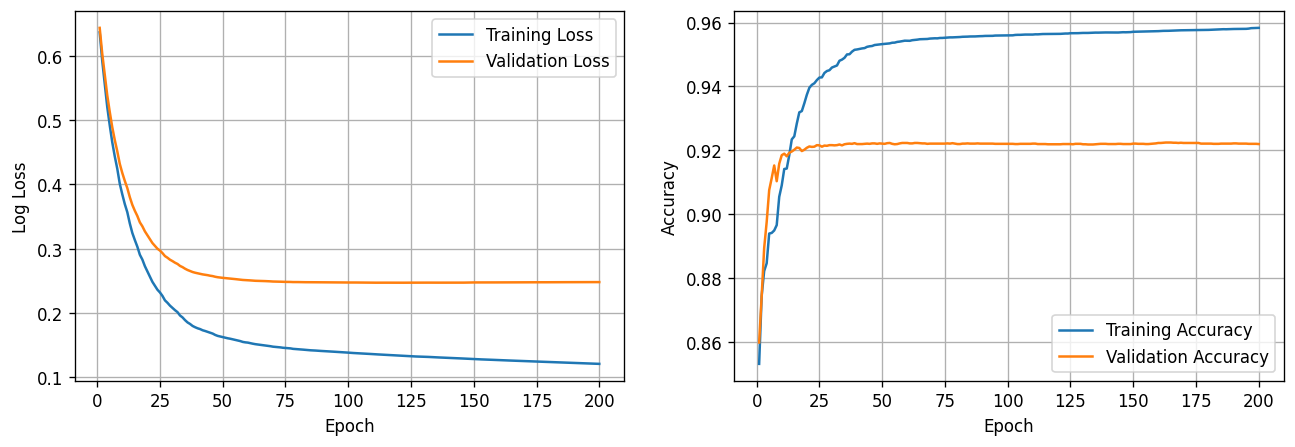

In [ ]:

plot_training_curves(history_df)

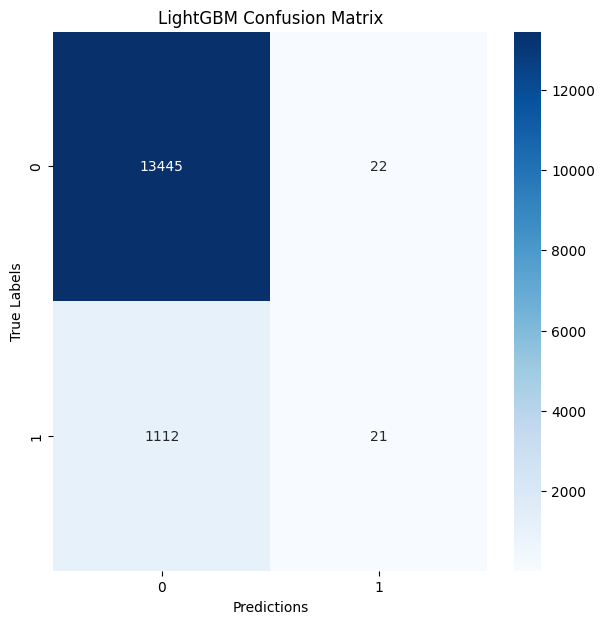

Accuracy: 0.9223287671232877

Classification Report:
               precision    recall  f1-score   support

           0       0.92      1.00      0.96     13467
           1       0.49      0.02      0.04      1133

    accuracy                           0.92     14600
   macro avg       0.71      0.51      0.50     14600
weighted avg       0.89      0.92      0.89     14600


Saved successfully to: /content/LGBM_ConfusionMatrix1.pdf


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

y_pred = lgb_model.predict(X_test)

plt.figure(figsize=(7,7), dpi=100)
sns.heatmap(confusion_matrix(y_test, y_pred), fmt='d', annot=True, cmap='Blues')
plt.xlabel('Predictions')
plt.ylabel('True Labels')
plt.title('LightGBM Confusion Matrix')

# THE FIX: Save locally to Colab instead of Google Drive
save_path = '/content/LGBM_ConfusionMatrix1.pdf'
plt.savefig(save_path, bbox_inches='tight')

plt.show()

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print(f"\nSaved successfully to: {save_path}")

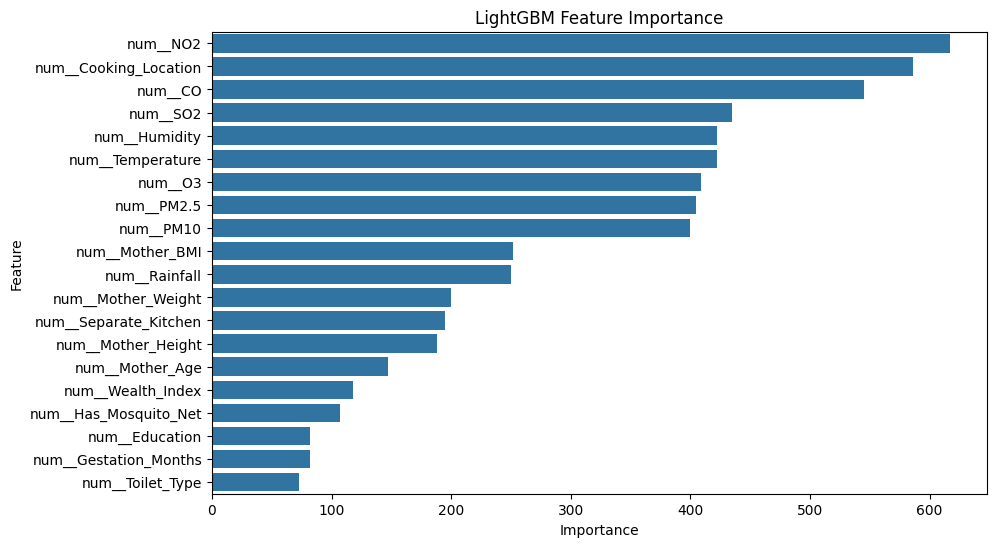

In [20]:

try:
    feature_names = preprocessor.get_feature_names_out()
except:
    num_names = numeric_feats
    cat_names = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_feats)
    feature_names = list(num_names) + list(cat_names)

importances = lgb_model.feature_importances_

feat_imp = pd.DataFrame({"Feature": feature_names, "Importance": importances})
feat_imp = feat_imp.sort_values("Importance", ascending=False).head(20)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feat_imp)
plt.title("LightGBM Feature Importance")
plt.show()


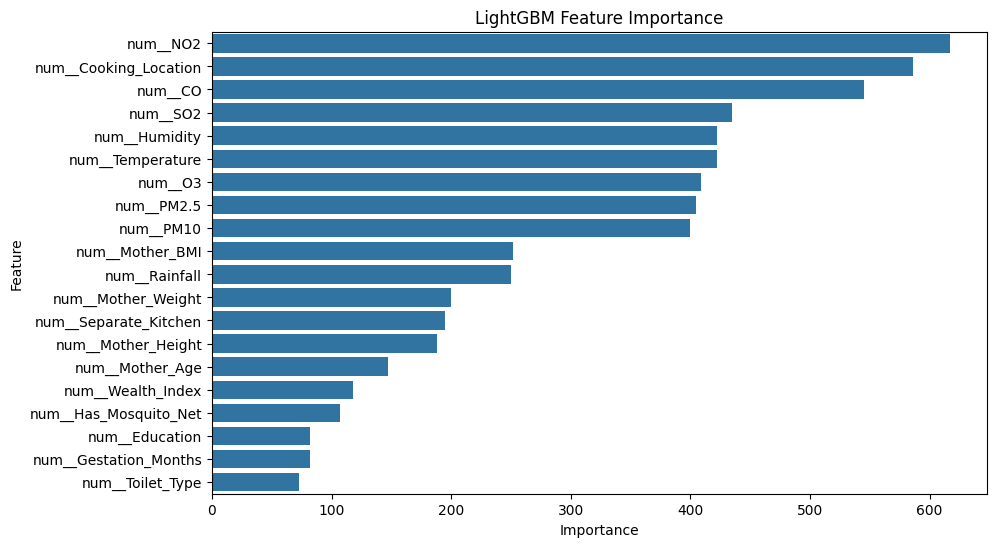

Saved successfully to: /content/feature_importanceLightGBM.pdf


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# THE FIX: Save locally to Colab instead of Google Drive
output_path = '/content/feature_importanceLightGBM.pdf'

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feat_imp)
plt.title("LightGBM Feature Importance")

plt.savefig(output_path, format='pdf', bbox_inches='tight')
plt.show()

print(f"Saved successfully to: {output_path}")

--- LightGBM Advanced Metrics ---
Log Loss: 0.2494
Matthews Correlation Coefficient (MCC): 0.0834



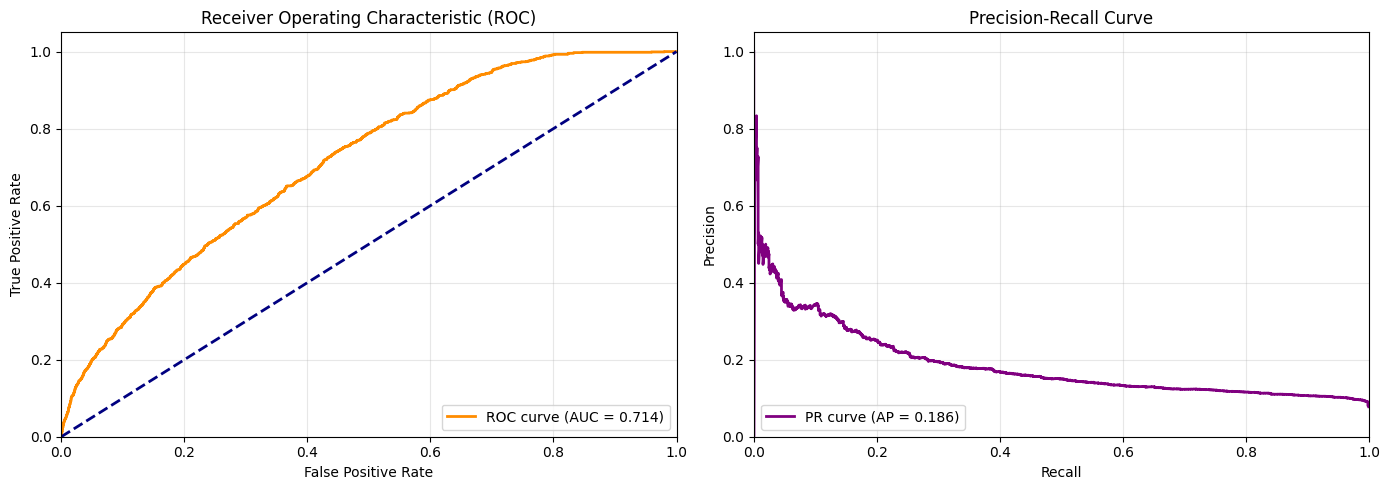


Plots displayed above and saved successfully to: /content/LGBM_ROC_PR_Curves.pdf


In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_curve, auc, precision_recall_curve,
                             average_precision_score, log_loss, matthews_corrcoef)

# 1. Get predictions and probabilities
y_pred = lgb_model.predict(X_test)
y_prob = lgb_model.predict_proba(X_test)
y_prob_pos = y_prob[:, 1]  # Probabilities specifically for the positive class (Preterm = 1)

# 2. Calculate Numerical Metrics
lgb_log_loss = log_loss(y_test, y_prob)
lgb_mcc = matthews_corrcoef(y_test, y_pred)

print("--- LightGBM Advanced Metrics ---")
print(f"Log Loss: {lgb_log_loss:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {lgb_mcc:.4f}\n")

# 3. Create Plots Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- ROC Curve ---
fpr, tpr, thresholds = roc_curve(y_test, y_prob_pos)
roc_auc = auc(fpr, tpr)
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Receiver Operating Characteristic (ROC)')
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)

# --- Precision-Recall Curve ---
precision, recall, _ = precision_recall_curve(y_test, y_prob_pos)
pr_auc = average_precision_score(y_test, y_prob_pos)
axes[1].plot(recall, precision, color='purple', lw=2, label=f'PR curve (AP = {pr_auc:.3f})')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(loc="lower left")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

# THE FIX: Save locally to Colab (bypassing Google Drive)
save_path = '/content/LGBM_ROC_PR_Curves.pdf'
plt.savefig(save_path, format='pdf', bbox_inches='tight')

# Display the plots right here in the notebook
plt.show()

print(f"\nPlots displayed above and saved successfully to: {save_path}")